# 02 – Cooler Anomaly Detection

This notebook builds and evaluates a cooler-focused anomaly detector
using the temperature features exported by Notebook 01.

## Objectives

- Create grouped training, validation, and test partitions.
- Train an Isolation Forest on nominal-cooler reference cycles.
- Calibrate an alert threshold using nominal validation cycles.
- Compare the model against a simple temperature threshold.
- Evaluate detection quality and false alarms.
- Save the model, feature schema, thresholds, and evaluation results.
- Verify predictions after loading the saved model.

## Scope

The experiment uses stable operating cycles.

A nominal cooler label describes the cooler only. Other components
may still be degraded during the same cycle.

Component labels support partitioning, reference selection, and
evaluation. Model inputs contain sensor features only.

## Data source

[Helwig, Pignanelli & Schütze (2015),
Condition monitoring of hydraulic systems, UCI Machine Learning Repository](https://doi.org/10.24432/C5CW21).

Dataset license: CC BY 4.0.

In [1]:
from pathlib import Path
import hashlib
import json
import platform

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold

import maintenance_copilot

PROJECT_ROOT = Path(maintenance_copilot.__file__).resolve().parents[2]

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
MODEL_DIR = PROJECT_ROOT / "models"

for directory in (FIGURE_DIR, TABLE_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_ESTIMATORS = 300
TARGET_FALSE_ALARM_RATE = 0.05

SENSORS = ("TS1", "TS2", "TS3", "TS4")
STATISTICS = ("mean", "std", "min", "max", "range", "slope")

FEATURE_COLUMNS = [
    f"{sensor}__{statistic}"
    for sensor in SENSORS
    for statistic in STATISTICS
]

CONDITION_COLUMNS = [
    "cooler_condition_pct",
    "valve_condition_pct",
    "pump_leakage",
    "accumulator_pressure_bar",
]

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0


In [2]:
feature_path = PROCESSED_DIR / "temperature_features.csv"
label_path = PROCESSED_DIR / "cycle_labels.csv"

for path in (feature_path, label_path):
    if not path.is_file():
        raise FileNotFoundError(
            f"Run Notebook 01 first. Missing file: {path}"
        )

X = pd.read_csv(feature_path, index_col="cycle_id")
labels = pd.read_csv(label_path, index_col="cycle_id")

if X.empty or not X.index.is_unique or X.index.hasnans:
    raise ValueError(
        "Features require nonempty, unique, nonmissing cycle IDs."
    )

if not labels.index.is_unique or not X.index.equals(labels.index):
    raise ValueError(
        "Feature and label cycle IDs must match in the same order."
    )

if not X.columns.is_unique or set(X.columns) != set(FEATURE_COLUMNS):
    raise ValueError(
        "Expected exactly the 24 temperature feature columns."
    )

if set(labels.columns) != set(CONDITION_COLUMNS + ["stability_flag"]):
    raise ValueError("Unexpected condition label columns.")

X = X.loc[:, FEATURE_COLUMNS].astype(float)

if not np.isfinite(X.to_numpy()).all():
    raise ValueError("Features contain missing or infinite values.")

allowed_values = {
    "cooler_condition_pct": {3, 20, 100},
    "valve_condition_pct": {73, 80, 90, 100},
    "pump_leakage": {0, 1, 2},
    "accumulator_pressure_bar": {90, 100, 115, 130},
    "stability_flag": {0, 1},
}

for column, allowed in allowed_values.items():
    if not labels[column].isin(allowed).all():
        raise ValueError(
            f"Unexpected or missing values in {column}."
        )

input_hashes = {
    path.name: hashlib.sha256(path.read_bytes()).hexdigest()
    for path in (feature_path, label_path)
}

print("Features:", X.shape)
print("Labels:", labels.shape)

Features: (2205, 24)
Labels: (2205, 5)


In [3]:
feature_path = PROCESSED_DIR / "temperature_features.csv"
label_path = PROCESSED_DIR / "cycle_labels.csv"

for path in (feature_path, label_path):
    if not path.is_file():
        raise FileNotFoundError(
            f"Run Notebook 01 first. Missing file: {path}"
        )

X = pd.read_csv(feature_path, index_col="cycle_id")
labels = pd.read_csv(label_path, index_col="cycle_id")

if X.empty or not X.index.is_unique or X.index.hasnans:
    raise ValueError(
        "Features require nonempty, unique, nonmissing cycle IDs."
    )

if not labels.index.is_unique or not X.index.equals(labels.index):
    raise ValueError(
        "Feature and label cycle IDs must match in the same order."
    )

if not X.columns.is_unique or set(X.columns) != set(FEATURE_COLUMNS):
    raise ValueError(
        "Expected exactly the 24 temperature feature columns."
    )

if set(labels.columns) != set(CONDITION_COLUMNS + ["stability_flag"]):
    raise ValueError("Unexpected condition label columns.")

X = X.loc[:, FEATURE_COLUMNS].astype(float)

if not np.isfinite(X.to_numpy()).all():
    raise ValueError("Features contain missing or infinite values.")

allowed_values = {
    "cooler_condition_pct": {3, 20, 100},
    "valve_condition_pct": {73, 80, 90, 100},
    "pump_leakage": {0, 1, 2},
    "accumulator_pressure_bar": {90, 100, 115, 130},
    "stability_flag": {0, 1},
}

for column, allowed in allowed_values.items():
    if not labels[column].isin(allowed).all():
        raise ValueError(
            f"Unexpected or missing values in {column}."
        )

input_hashes = {
    path.name: hashlib.sha256(path.read_bytes()).hexdigest()
    for path in (feature_path, label_path)
}

print("Features:", X.shape)
print("Labels:", labels.shape)

Features: (2205, 24)
Labels: (2205, 5)


## Grouped Train, Validation, and Test Split

We retain cycles with confirmed stability.

A group contains every cycle sharing the same combination of:

- Cooler condition
- Valve condition
- Pump leakage
- Accumulator pressure

All occurrences of a combination remain in one partition, including
occurrences that are not adjacent in the original files.

We create five stratified group folds and assign:

| Folds | Partition | Approximate share |
|---|---|---:|
| 2, 3, 4 | Training | 60% |
| 1 | Validation | 20% |
| 0 | Test | 20% |

The training reference contains nominal-cooler training cycles only.

Nominal-cooler validation cycles determine the alert thresholds.
The test partition evaluates the fixed models and thresholds.

This is an evaluation on held-out condition combinations from one test
rig. Performance on future periods and other machines requires
additional evaluation.

In [4]:
metadata = labels.loc[
    labels["stability_flag"].eq(0)
].copy()

combinations = pd.MultiIndex.from_frame(
    metadata[CONDITION_COLUMNS]
)

metadata["condition_group"] = pd.factorize(
    combinations,
    sort=True,
)[0]

coverage = metadata.groupby(
    "cooler_condition_pct"
)["condition_group"].nunique()

if set(coverage.index) != {3, 20, 100} or coverage.min() < 5:
    raise ValueError(
        "At least five groups per cooler condition are required."
    )

splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

fold_ids = np.full(len(metadata), -1, dtype=int)

for fold, (_, held_out_positions) in enumerate(
    splitter.split(
        X.loc[metadata.index],
        y=metadata["cooler_condition_pct"],
        groups=metadata["condition_group"],
    )
):
    fold_ids[held_out_positions] = fold

metadata["fold"] = fold_ids

metadata["split"] = metadata["fold"].map(
    {
        0: "test",
        1: "validation",
        2: "train",
        3: "train",
        4: "train",
    }
)

metadata["is_degraded"] = (
    metadata["cooler_condition_pct"].ne(100).astype(int)
)

if metadata["split"].isna().any():
    raise RuntimeError(
        "Some cycles were not assigned to a partition."
    )

if metadata.groupby("condition_group")["split"].nunique().max() != 1:
    raise RuntimeError(
        "A condition group appears in multiple partitions."
    )

for split_name, subset in metadata.groupby("split"):
    if set(subset["cooler_condition_pct"]) != {3, 20, 100}:
        raise ValueError(
            f"Missing cooler condition in {split_name}."
        )

split_summary = pd.crosstab(
    metadata["split"],
    metadata["cooler_condition_pct"],
).reindex(
    index=["train", "validation", "test"],
    columns=[100, 20, 3],
)

split_summary["total_cycles"] = split_summary.sum(axis=1)

split_summary["condition_groups"] = (
    metadata.groupby("split")["condition_group"].nunique()
)

split_summary

cooler_condition_pct,100,20,3,total_cycles,condition_groups
split,,,,,
train,289,300,280,869,86
validation,100,90,100,290,29
test,100,90,100,290,29


In [5]:
train_reference_ids = metadata.index[
    metadata["split"].eq("train")
    & metadata["cooler_condition_pct"].eq(100)
]

calibration_ids = metadata.index[
    metadata["split"].eq("validation")
    & metadata["cooler_condition_pct"].eq(100)
]

test_ids = metadata.index[
    metadata["split"].eq("test")
]

if len(train_reference_ids) < 20 or len(calibration_ids) < 20:
    raise ValueError(
        "Insufficient nominal training or calibration cycles."
    )

X_train_reference = X.loc[train_reference_ids]
X_calibration = X.loc[calibration_ids]

print(
    "Nominal cooler training cycles:",
    len(X_train_reference),
)

print(
    "Nominal cooler calibration cycles:",
    len(X_calibration),
)

print(
    "Test cycles, all cooler conditions:",
    len(test_ids),
)

Nominal cooler training cycles: 289
Nominal cooler calibration cycles: 100
Test cycles, all cooler conditions: 290


## Training and Threshold Calibration

The Isolation Forest learns a reference distribution from
nominal-cooler training cycles.

We define the anomaly score as:

`anomaly_score = -model.score_samples(features)`

Larger scores indicate stronger deviations from the learned reference.

### Alert threshold

The threshold is the upper 95th percentile of anomaly scores from
nominal-cooler validation cycles.

A cycle triggers an alert when its score is strictly greater than
the threshold.

The target false alarm rate is 5% on the nominal calibration sample.
The realized rate on future data can differ.

We use our calibrated threshold instead of the estimator's default
prediction threshold.

### Simple comparison baseline

Notebook 01 showed an association between cooler degradation and
higher temperatures.

We therefore also evaluate a threshold on the TS1 cycle mean.
Its threshold uses the same nominal validation cycles and quantile rule.

Model settings, score directions, and calibration rules are fixed
before examining test results.

In [6]:
model = IsolationForest(
    n_estimators=N_ESTIMATORS,
    max_samples="auto",
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(X_train_reference)

# Negate score_samples so larger values mean more anomalous observations.
calibration_scores = -model.score_samples(X_calibration)

anomaly_threshold = float(
    np.quantile(
        calibration_scores,
        1 - TARGET_FALSE_ALARM_RATE,
        method="higher",
    )
)

ts1_threshold = float(
    np.quantile(
        X_calibration["TS1__mean"],
        1 - TARGET_FALSE_ALARM_RATE,
        method="higher",
    )
)

calibration_summary = pd.DataFrame(
    {
        "method": [
            "isolation_forest",
            "ts1_mean_threshold",
        ],
        "threshold": [
            anomaly_threshold,
            ts1_threshold,
        ],
        "nominal_validation_false_alarm_rate": [
            float(
                (calibration_scores > anomaly_threshold).mean()
            ),
            float(
                (X_calibration["TS1__mean"] > ts1_threshold).mean()
            ),
        ],
    }
)

calibration_summary

,method,threshold,nominal_validation_false_alarm_rate
0,isolation_forest,0.519208,0.04
1,ts1_mean_threshold,36.363233,0.04


## Evaluation

For evaluation, the positive class is cooler degradation:

- `0`: Nominal cooler, condition = 100%
- `1`: Degraded cooler, condition = 20% or 3%

We report:

| Metric | Interpretation |
|---|---|
| Precision | Fraction of alerts associated with a degraded cooler |
| Recall | Fraction of degraded-cooler cycles detected |
| F1 | Harmonic mean of precision and recall |
| Balanced accuracy | Average recall across nominal and degraded classes |
| ROC AUC | Ranking quality across score thresholds |
| Average precision | Precision-recall ranking summary |
| False alarm rate | Fraction of nominal-cooler cycles triggering an alert |

A false alarm is defined relative to the cooler label. Other components
may still be degraded in a nominal-cooler cycle.

Validation results include the cycles used to calibrate the thresholds.
Test results evaluate the fixed thresholds on a separate partition.

Test results must not be used to retune the model or thresholds.

In [7]:
def evaluate_predictions(y_true, scores, alerts):
    """Evaluate degraded cooler = 1 and nominal cooler = 0."""
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    alerts = np.asarray(alerts, dtype=int)

    if set(np.unique(y_true)) != {0, 1}:
        raise ValueError(
            "Evaluation requires both cooler classes."
        )

    if scores.shape != y_true.shape or alerts.shape != y_true.shape:
        raise ValueError(
            "Labels, scores, and alerts must be aligned."
        )

    if not np.isfinite(scores).all():
        raise ValueError("Evaluation scores must be finite.")

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        alerts,
        labels=[0, 1],
    ).ravel()

    return {
        "cycles": len(y_true),
        "degraded_prevalence": float(y_true.mean()),
        "precision": float(
            precision_score(y_true, alerts, zero_division=0)
        ),
        "recall": float(
            recall_score(y_true, alerts, zero_division=0)
        ),
        "f1": float(
            f1_score(y_true, alerts, zero_division=0)
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, alerts)
        ),
        "roc_auc": float(
            roc_auc_score(y_true, scores)
        ),
        "average_precision": float(
            average_precision_score(y_true, scores)
        ),
        "false_alarm_rate": float(fp / (fp + tn)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

In [8]:
metric_rows = []
predictions_by_split = {}

for split_name in ("validation", "test"):
    ids = metadata.index[
        metadata["split"].eq(split_name)
    ]

    result = metadata.loc[
        ids,
        ["cooler_condition_pct", "is_degraded"],
    ].copy()

    result["anomaly_score"] = -model.score_samples(
        X.loc[ids]
    )

    result["is_anomaly"] = (
        result["anomaly_score"] > anomaly_threshold
    )

    result["ts1_mean_score"] = X.loc[ids, "TS1__mean"]

    result["ts1_mean_alert"] = (
        result["ts1_mean_score"] > ts1_threshold
    )

    for method, score_column, alert_column in (
        ("isolation_forest", "anomaly_score", "is_anomaly"),
        ("ts1_mean_threshold", "ts1_mean_score", "ts1_mean_alert"),
    ):
        metrics = evaluate_predictions(
            result["is_degraded"],
            result[score_column],
            result[alert_column],
        )

        metric_rows.append(
            {
                "split": split_name,
                "method": method,
                **metrics,
            }
        )

    predictions_by_split[split_name] = result

metrics_table = pd.DataFrame(metric_rows)
test_predictions = predictions_by_split["test"]

metrics_table.set_index(["split", "method"]).round(4)

cycles  degraded_prevalence  precision  recall  \
split      method                                                               
validation isolation_forest       290               0.6552     0.9794     1.0   
           ts1_mean_threshold     290               0.6552     0.9794     1.0   
test       isolation_forest       290               0.6552     0.9896     1.0   
           ts1_mean_threshold     290               0.6552     0.9948     1.0   

                                   f1  balanced_accuracy  roc_auc  \
split      method                                                   
validation isolation_forest    0.9896              0.980      1.0   
           ts1_mean_threshold  0.9896              0.980      1.0   
test       isolation_forest    0.9948              0.990      1.0   
           ts1_mean_threshold  0.9974              0.995      1.0   

                               average_precision  false_alarm_rate  tn  fp  \
split      method                                                            
validation isolation_forest                  1.0              0.04  96   4   
           ts1_mean_threshold                1.0              0.04  96   4   
test       isolation_forest                  1.0              0.02  98   2   
           ts1_mean_threshold                1.0              0.01  99   1   

                               fn   tp  
split      method                       
validation isolation_forest     0  190  
           ts1_mean_threshold   0  190  
test       isolation_forest     0  190  
           ts1_mean_threshold   0  190

In [9]:
condition_results = (
    test_predictions.groupby("cooler_condition_pct")
    .agg(
        cycles=("is_degraded", "size"),
        isolation_forest_alert_rate=("is_anomaly", "mean"),
        ts1_threshold_alert_rate=("ts1_mean_alert", "mean"),
        median_anomaly_score=("anomaly_score", "median"),
    )
    .reindex([100, 20, 3])
)

condition_results.round(4)

,cycles,isolation_forest_alert_rate,ts1_threshold_alert_rate,median_anomaly_score
cooler_condition_pct,,,,
100,100,0.02,0.01,0.4727
20,90,1.00,1.00,0.6299
3,100,1.00,1.00,0.6431


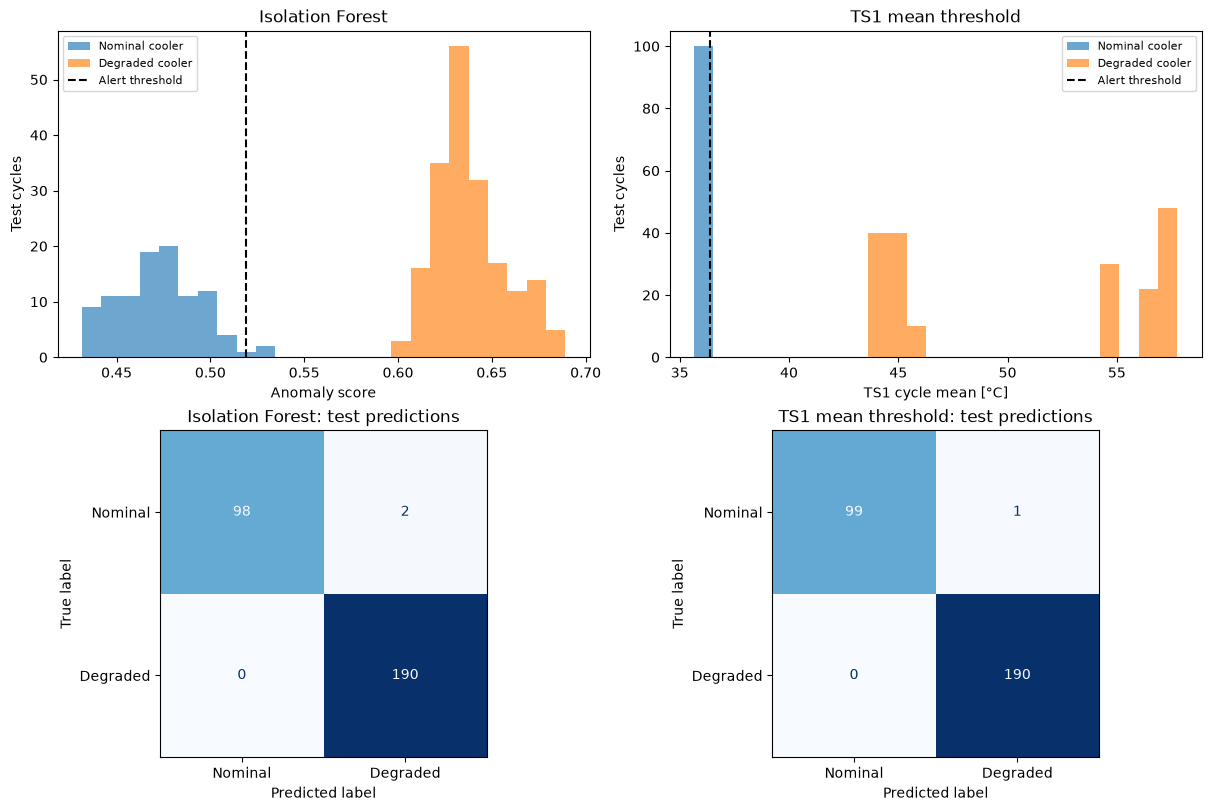

In [10]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    constrained_layout=True,
)

plot_methods = [
    (
        "Isolation Forest",
        "anomaly_score",
        "is_anomaly",
        anomaly_threshold,
    ),
    (
        "TS1 mean threshold",
        "ts1_mean_score",
        "ts1_mean_alert",
        ts1_threshold,
    ),
]

for column, (
    title,
    score_col,
    alert_col,
    threshold,
) in enumerate(plot_methods):
    ax = axes[0, column]

    bins = np.histogram_bin_edges(
        test_predictions[score_col],
        bins=25,
    )

    for target, label, color in (
        (0, "Nominal cooler", "tab:blue"),
        (1, "Degraded cooler", "tab:orange"),
    ):
        mask = test_predictions["is_degraded"].eq(target)

        ax.hist(
            test_predictions.loc[mask, score_col],
            bins=bins,
            alpha=0.65,
            color=color,
            label=label,
        )

    ax.axvline(
        threshold,
        color="black",
        linestyle="--",
        label="Alert threshold",
    )

    ax.set(
        title=title,
        xlabel=(
            "Anomaly score"
            if column == 0
            else "TS1 cycle mean [°C]"
        ),
        ylabel="Test cycles",
    )

    ax.legend(fontsize=8)

    ConfusionMatrixDisplay.from_predictions(
        test_predictions["is_degraded"],
        test_predictions[alert_col].astype(int),
        labels=[0, 1],
        display_labels=["Nominal", "Degraded"],
        cmap="Blues",
        colorbar=False,
        ax=axes[1, column],
    )

    axes[1, column].set_title(
        f"{title}: test predictions"
    )

figure_path = FIGURE_DIR / "cooler_baseline_evaluation.png"

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

## Save the Model and Evaluation Artifacts

The saved model bundle contains:

- The fitted Isolation Forest.
- The expected feature names and feature extraction specification.
- The anomaly threshold and TS1 comparison threshold.
- Training and calibration cycle IDs.
- Reference feature medians.
- Input file hashes and software versions.

We also save partition assignments, test predictions, summary tables,
and a JSON evaluation report.

The model remains fitted on the original training reference. This
preserves the relationship between the fitted model, calibrated
threshold, and reported test results.

The following cells reload the saved bundle and verify that it
reproduces the test predictions.

In [11]:
versions = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "joblib": joblib.__version__,
}

artifact = {
    "artifact_version": 1,
    "component_scope": "cooler",
    "stable_cycles_only": True,
    "nominal_cooler_condition_pct": 100,
    "model": model,
    "feature_columns": FEATURE_COLUMNS,
    "feature_spec": {
        "sensors": list(SENSORS),
        "samples_per_cycle": 60,
        "sampling_rate_hz": 1.0,
        "statistics": list(STATISTICS),
        "std_ddof": 0,
        "slope_method": (
            "Least-squares linear trend "
            "in degrees Celsius per second"
        ),
    },
    "anomaly_threshold": anomaly_threshold,
    "ts1_threshold": ts1_threshold,
    "score_definition": (
        "Negative score_samples; larger values are more anomalous"
    ),
    "target_false_alarm_rate": TARGET_FALSE_ALARM_RATE,
    "training_cycle_ids": train_reference_ids.tolist(),
    "calibration_cycle_ids": calibration_ids.tolist(),
    "reference_feature_medians": (
        X_train_reference.median().to_dict()
    ),
    "random_state": RANDOM_STATE,
    "input_sha256": input_hashes,
    "versions": versions,
}

model_path = MODEL_DIR / "cooler_isolation_forest.joblib"

joblib.dump(artifact, model_path)

metadata.to_csv(
    PROCESSED_DIR / "cooler_split_metadata.csv"
)

test_predictions.to_csv(
    PROCESSED_DIR / "cooler_test_predictions.csv"
)

split_summary.to_csv(
    TABLE_DIR / "cooler_split_summary.csv"
)

calibration_summary.to_csv(
    TABLE_DIR / "cooler_calibration.csv",
    index=False,
)

metrics_table.to_csv(
    TABLE_DIR / "cooler_baseline_metrics.csv",
    index=False,
)

condition_results.to_csv(
    TABLE_DIR / "cooler_test_condition_results.csv"
)

report = {
    "component_scope": "cooler",
    "evaluation_scope": (
        "Development benchmark on held-out condition combinations"
    ),
    "random_state": RANDOM_STATE,
    "n_estimators": N_ESTIMATORS,
    "target_false_alarm_rate": TARGET_FALSE_ALARM_RATE,
    "anomaly_threshold": anomaly_threshold,
    "ts1_threshold": ts1_threshold,
    "split_method": (
        "StratifiedGroupKFold: fold 0 test, "
        "fold 1 validation, others train"
    ),
    "metrics": metric_rows,
    "input_sha256": input_hashes,
    "versions": versions,
}

report_path = (
    PROJECT_ROOT / "reports" / "cooler_baseline_report.json"
)

report_path.write_text(
    json.dumps(report, indent=2, allow_nan=False) + "\n",
    encoding="utf-8",
)

print(
    "Saved model:",
    model_path.relative_to(PROJECT_ROOT),
)

print(
    "Saved report:",
    report_path.relative_to(PROJECT_ROOT),
)

Saved model: models/cooler_isolation_forest.joblib
Saved report: reports/cooler_baseline_report.json


In [12]:
def predict_cycles(bundle, feature_frame):
    """Score completed cycles using sensor features only."""
    expected = bundle["feature_columns"]

    if (
        not feature_frame.columns.is_unique
        or set(feature_frame.columns) != set(expected)
    ):
        raise ValueError(
            "Input columns do not match the saved feature schema."
        )

    if (
        feature_frame.empty
        or not feature_frame.index.is_unique
        or feature_frame.index.hasnans
    ):
        raise ValueError(
            "Provide at least one cycle with unique, nonmissing cycle IDs."
        )

    ordered = feature_frame.loc[:, expected].astype(float)

    if not np.isfinite(ordered.to_numpy()).all():
        raise ValueError("Input features must be finite.")

    scores = -bundle["model"].score_samples(ordered)

    return pd.DataFrame(
        {
            "anomaly_score": scores,
            "anomaly_threshold": bundle["anomaly_threshold"],
            "is_anomaly": scores > bundle["anomaly_threshold"],
            "ts1_mean_c": ordered["TS1__mean"],
            "ts1_threshold_c": bundle["ts1_threshold"],
            "ts1_mean_alert": (
                ordered["TS1__mean"] > bundle["ts1_threshold"]
            ),
        },
        index=ordered.index,
    )


loaded_artifact = joblib.load(model_path)

reloaded_predictions = predict_cycles(
    loaded_artifact,
    X.loc[test_ids],
)

np.testing.assert_allclose(
    reloaded_predictions["anomaly_score"],
    test_predictions["anomaly_score"],
)

np.testing.assert_array_equal(
    reloaded_predictions["is_anomaly"],
    test_predictions["is_anomaly"],
)

print("Reloaded model reproduces the test scores and alerts.")

Reloaded model reproduces the test scores and alerts.


In [13]:
# Select one example per known cooler condition for demonstration only.
example_ids = (
    test_predictions.groupby("cooler_condition_pct")
    .head(1)
    .index
)

# Labels are not passed to the prediction function.
example_predictions = predict_cycles(
    loaded_artifact,
    X.loc[example_ids],
)

example_predictions.join(
    labels.loc[
        example_ids,
        ["cooler_condition_pct"],
    ]
).round(4)

,anomaly_score,anomaly_threshold,is_anomaly,ts1_mean_c,ts1_threshold_c,ts1_mean_alert,cooler_condition_pct
cycle_id,,,,,,,
283,0.6596,0.5192,True,54.4046,36.3632,True,3
944,0.6071,0.5192,True,46.1653,36.3632,True,20
1686,0.4977,0.5192,False,35.6515,36.3632,False,100


## Interpretation and Next Steps

### What this experiment demonstrates

The workflow trains a nominal-reference anomaly detector, calibrates
an alert threshold, evaluates held-out condition groups, and reproduces
predictions from a saved model bundle.

The temperature threshold provides a simple comparison for assessing
whether the Isolation Forest adds practical value.

Model complexity should be justified by detection quality, false alarms,
robustness, or operational requirements.

### Limitations

- The full dataset informed the exploration in Notebook 01.
  These results are therefore development-benchmark results.
- Evaluation uses one grouped split from a single test rig.
- Grouping separates exact condition combinations, while temporal
  dependence and shared experimental conditions may remain.
- The reference is nominal for the cooler. Other components may
  still be degraded.
- False alarm rates measured on calibration and test data can differ.
- Predictions require features from a completed 60-second cycle.
- Anomaly scores measure deviations from the learned reference.
  Failure probabilities and physical root causes require additional
  modeling and evidence.
- Strong results on these cooler conditions do not establish
  performance on other machines or fault types.

### Next implementation step

Move feature extraction, training, and prediction into reusable
Python modules.

Add focused tests for feature alignment, partition separation,
threshold behavior, and prediction consistency.

Then build structured anomaly events that can support the maintenance
copilot and document retrieval workflow.